<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; margin:0'>Challenge 9 — Deep Learning III</h1>
<h2 style='color:white; margin:0'>Generative Adversarial Networks (GAN) para imágenes biomédicas sintéticas</h2>
<p style='color:white; margin:0'><b>Curso:</b> Reconocimiento de Patrones — Ingeniería Biomédica</p>
<p style='color:white; margin:0'>
</div>

## Contexto clínico

En imágenes biomédicas, los modelos generativos pueden utilizarse para **aumentar datos**, explorar variabilidad morfológica o crear datos sintéticos cuando el acceso a imágenes reales es limitado por privacidad, costo o disponibilidad.

En este challenge trabajaremos con un conjunto **sintético y autocontenido** de imágenes tipo células/nódulos de baja resolución. La idea no es generar imágenes clínicas listas para diagnóstico, sino comprender el mecanismo básico de una **GAN**:

- un **Generador (G)** aprende a producir imágenes falsas;
- un **Discriminador (D)** aprende a distinguir imágenes reales de imágenes generadas;
- ambos modelos se entrenan en competencia mediante una pérdida adversarial.



## Resultados de aprendizaje

Al finalizar el challenge, el estudiante debe ser capaz de:

1. Explicar la diferencia entre un modelo discriminativo y un modelo generativo.
2. Identificar los componentes de una GAN: generador, discriminador, ruido latente y pérdida adversarial.
3. Implementar una GAN simple en PyTorch para imágenes biomédicas sintéticas.
4. Interpretar curvas de pérdida, muestras generadas y señales de entrenamiento inestable.
5. Discutir limitaciones éticas y clínicas del uso de imágenes sintéticas en salud.

---

## Distribución sugerida

**Parte in-class:**  
- Concepto de GAN.
- Generación del dataset sintético.
- Arquitectura de G y D.
- Primeras épocas de entrenamiento.

**Parte at-home:**  
- Ejecutar entrenamiento completo.
- Analizar imágenes generadas.
- Comparar estadísticas reales vs generadas.
- Reflexionar sobre riesgos clínicos y posibles usos.

---

## 1. Diseño conceptual

### 1.1 — ¿Qué problema resuelve una GAN?

**Pregunta C1:** Explica brevemente qué intenta aprender una GAN.

Respuesta:  
Una GAN (Generative Adversarial Network) intenta aprender la distribución de los datos reales para generar nuevas muestras que sean lo más parecidas posible a las originales. Para ello utiliza dos redes neuronales: un generador, que crea datos sintéticos, y un discriminador, que intenta distinguir entre datos reales y generados. Mediante esta competencia, el generador aprende progresivamente a producir datos cada vez más realistas.

### 1.2 — Componentes principales

Completa la tabla:

| Componente | Rol |
|---|---|
| Ruido latente `z` | Vector de entrada aleatorio que sirve como punto de partida para generar nuevas muestras. |
| Generador `G(z)` | Crea datos sintéticos a partir del ruido latente intentando que parezcan reales. |
| Discriminador `D(x)` | Evalúa una muestra y determina si es real o generada por el generador. |
| Pérdida adversarial | Función de costo que guía el entrenamiento competitivo entre generador y discriminador. |

### 1.3 — Interpretación biomédica

**Pregunta C2:** ¿Por qué una imagen biomédica sintética no debe usarse automáticamente como evidencia clínica?

Respuesta:  
Porque una imagen sintética es generada por un modelo y puede contener errores, artefactos o características que no corresponden a la realidad biológica del paciente. Aunque sea visualmente realista, no reemplaza una adquisición clínica real ni la validación por especialistas, por lo que debe utilizarse únicamente con fines de investigación, entrenamiento o aumento de datos.


---
## 2.1 — Librerías y configuración

In [ ]:
# ── Estilo visual y configuración general ────────────────────────────────
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

torch.set_num_threads(1)

UPCH_RED = '#8B0000'

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)

# TODO 1: selecciona el dispositivo de ejecución.
device = ___

print("Device:", device)
print("PyTorch:", torch.__version__)


Device: 
PyTorch: 2.11.0+cpu


---

## 2. Dataset sintético autocontenido

Generaremos imágenes `28 x 28` con patrones suaves tipo célula/nódulo.  
Cada imagen tendrá una o más regiones brillantes, variabilidad de forma e intensidad, y ruido leve.

Este dataset cumple dos objetivos:

1. Evitar descarga de datos externos.
2. Permitir que la GAN aprenda una distribución visual simple en poco tiempo.

In [ ]:
def generate_synthetic_biomedical_images(n_samples=256, img_size=28, seed=42):
    rng = np.random.default_rng(seed)
    xs = np.linspace(-1, 1, img_size)
    yy, xx = np.meshgrid(xs, xs)
    images = []

    for _ in range(n_samples):
        img = np.zeros((img_size, img_size), dtype=np.float32)

        n_blobs = rng.integers(1, 3)
        for _ in range(n_blobs):
            cx, cy = rng.uniform(-0.30, 0.30, size=2)
            sx, sy = rng.uniform(0.09, 0.22, size=2)
            amp = rng.uniform(0.60, 1.00)
            blob = amp * np.exp(-(((xx - cx) ** 2) / (2 * sx ** 2) +
                                  ((yy - cy) ** 2) / (2 * sy ** 2)))
            img += blob

        if rng.random() < 0.60:
            cx, cy = rng.uniform(-0.20, 0.20, size=2)
            s = rng.uniform(0.35, 0.50)
            halo = 0.20 * np.exp(-(((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * s ** 2)))
            img += halo

        img += rng.normal(0, 0.04, size=(img_size, img_size))

        # TODO 2: normaliza cada imagen al rango [0, 1].
        img = img - img.min()
        img = img / (img.max() + 1e-8)

        images.append(img.astype(np.float32))

    # TODO 3: convierte la lista a un arreglo con forma (N, C, H, W).
    X = np.array(images, dtype=np.float32)[:, np.newaxis, :, :]
    return X

X_real = generate_synthetic_biomedical_images(n_samples=256, img_size=28, seed=42)

print("Forma del dataset:", X_real.shape)
print("Rango de intensidades:", X_real.min(), "a", X_real.max())


Forma del dataset: (256, 1, 28, 28)
Rango de intensidades: 0.0 a 1.0


### Paso 2.1 — Visualización del dataset real sintético

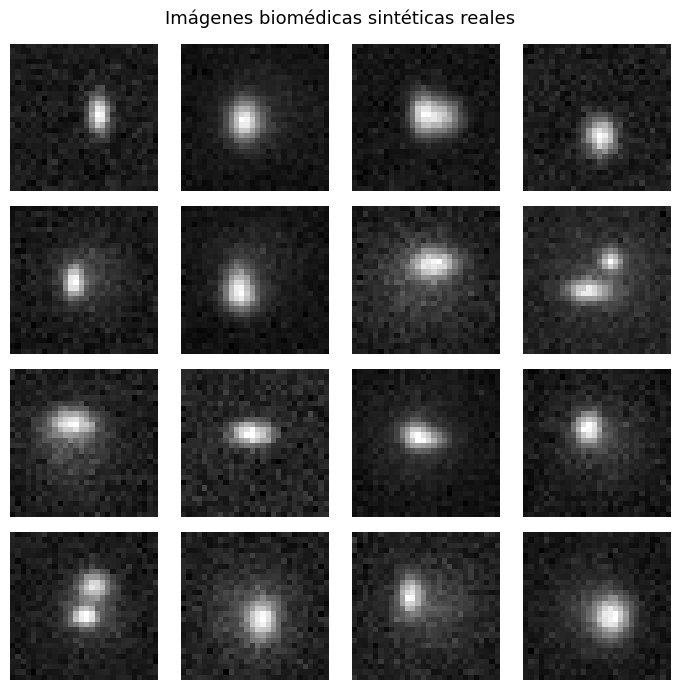

In [ ]:
def show_image_grid(images, title="", n=16, cmap="gray"):
    images = images[:n]
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(7, 7))
    for i, img in enumerate(images):
        plt.subplot(nrows, ncols, i + 1)
        if isinstance(img, torch.Tensor):
            img = img.detach().cpu().numpy()
        img = np.squeeze(img)
        plt.imshow(img, cmap=cmap, vmin=0, vmax=1)
        plt.axis("off")
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

show_image_grid(X_real, title="Imágenes biomédicas sintéticas reales", n=16)

### Paso 2.2 — Normalización para GAN y DataLoader

El generador usará `tanh`, por lo que sus imágenes estarán en el rango `[-1, 1]`.  
Para entrenar de forma consistente, también transformaremos las imágenes reales de `[0, 1]` a `[-1, 1]`:

\[
x_{gan} = 2x - 1
\]

In [ ]:
# ── Normalización para GAN ───────────────────────────────────────────────

# TODO 4: transforma las imágenes reales de [0, 1] a [-1, 1].
X_gan = 2* X_real -1

# TODO 5: convierte X_gan a tensor float32.
X_tensor = torch.tensor(X_gan, dtype=torch.float32)

# TODO 6: crea TensorDataset para entrenamiento no supervisado.
dataset = TensorDataset(X_tensor)

batch_size = 32
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

real_batch = next(iter(train_loader))[0]
print("Batch:", real_batch.shape)
print("Rango batch:", real_batch.min().item(), "a", real_batch.max().item())


Batch: torch.Size([32, 1, 28, 28])
Rango batch: -1.0 a 1.0


---

## 3. Arquitectura GAN

Usaremos una GAN simple con capas totalmente conectadas.  
Esto permite concentrarnos en la lógica adversarial sin sobrecargar el challenge con una DCGAN completa.

### Generador

Entrada: vector latente `z` de dimensión 16.  
Salida: imagen generada `1 x 28 x 28`.

### Discriminador

Entrada: imagen `1 x 28 x 28`.  
Salida: un **logit**. No usamos `sigmoid` en el modelo porque `BCEWithLogitsLoss` ya la incorpora internamente.

In [ ]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class Generator(nn.Module):
    def __init__(self, latent_dim=16, img_size=28):
        super().__init__()
        self.img_size = img_size
        self.net = nn.Sequential(
            # TODO 7: completa la primera capa del generador según la descripción de la arquitectura.
            nn.Linear(latent_dim, 64),
            nn.ReLU(inplace=True),

            # TODO 8: completa la segunda capa oculta.
            nn.Linear(64, 128),
            nn.ReLU(inplace=True),

            # TODO 9: completa la capa de salida.
            nn.Linear(128, img_size * img_size),

            # TODO 10: completa la activación final del generador.
            nn.Tanh()
        )

    def forward(self, z):
        x = self.net(z)

        # TODO 11: reordena la salida a forma de imagen.
        x = x.view(z.size(0), 1, self.img_size, self.img_size)
        return x


class Discriminator(nn.Module):
    def __init__(self, img_size=28):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),

            # TODO 12: completa la primera capa del discriminador.
            nn.Linear(img_size * img_size, 128),
            nn.LeakyReLU(0.2, inplace=True),

            # TODO 13: completa la salida del discriminador.
            nn.Linear(128, 1)
        )

    def forward(self, x):
        logits = self.net(x).squeeze(1)
        return logits


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


latent_dim = 16
G = Generator(latent_dim=latent_dim).to(device)
D = Discriminator().to(device)

print(G)
print(D)
print("Parámetros G:", count_parameters(G))
print("Parámetros D:", count_parameters(D))


Device: cpu
Generator(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=128, out_features=784, bias=True)
    (5): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)
Parámetros G: 110544
Parámetros D: 100609


---

## 4. Entrenamiento adversarial

En cada batch realizaremos dos pasos:

1. **Actualizar el discriminador:**  
   aprende a clasificar imágenes reales como reales e imágenes generadas como falsas.

2. **Actualizar el generador:**  
   aprende a producir imágenes que el discriminador clasifique como reales.

Usaremos `BCEWithLogitsLoss`, porque el discriminador entrega logits.

In [ ]:
# ── Función de pérdida y optimizadores ──────────────────────────────────
import torch.optim as optim
# TODO 14: define la pérdida adversarial para logits binarios.
loss_fn = nn.BCEWithLogitsLoss()
# TODO 15: define optimizadores para G y D.
optimizer_G = optim.Adam(G.parameters(), lr=0.0002)
optimizer_D = optim.Adam(D.parameters(), lr=0.0002)

history = {
    "g_loss": [],
    "d_loss": [],
    "d_real_score": [],
    "d_fake_score": []
}

def train_gan(G, D, train_loader, epochs=8, latent_dim=16, device="cpu"):
    for epoch in range(1, epochs + 1):
        g_losses, d_losses = [], []
        d_real_scores, d_fake_scores = [], []

        for (real_imgs,) in train_loader:
            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)

            # ------------------------------------------------------------
            # 1) Entrenar Discriminador
            # ------------------------------------------------------------

            # TODO 16: genera imágenes falsas para entrenar el discriminador.
            z = torch.randn(batch_size, latent_dim, device=device)
            fake_imgs = G(z).detach()

            real_labels = torch.full((batch_size,), 0.9, device=device)
            fake_labels = torch.zeros(batch_size, device=device)

            # TODO 17: calcula logits para imágenes reales y falsas.
            real_logits = D(real_imgs)
            fake_logits = D(fake_imgs)

            d_loss_real = loss_fn(real_logits, real_labels)
            d_loss_fake = loss_fn(fake_logits, fake_labels)
            d_loss = d_loss_real + d_loss_fake

            optimizer_D.zero_grad()

            # TODO 18: ejecuta backpropagation y actualización del discriminador.
            d_loss.backward()
            optimizer_D.step()

            # ------------------------------------------------------------
            # 2) Entrenar Generador
            # ------------------------------------------------------------

            # TODO 19: genera nuevas imágenes falsas y evalúalas con el discriminador.
            z = torch.randn(batch_size, latent_dim, device=device)
            fake_imgs = G(z)
            fake_logits = D(fake_imgs)

            target_real = torch.ones(batch_size, device=device)

            # TODO 20: calcula la pérdida del generador.
            g_loss = loss_fn(fake_logits, target_real)

            optimizer_G.zero_grad()

            # TODO 21: ejecuta backpropagation y actualización del generador.
            g_loss.backward()
            optimizer_G.step()
            ___

            g_losses.append(g_loss.item())
            d_losses.append(d_loss.item())
            d_real_scores.append(torch.sigmoid(real_logits).mean().item())
            d_fake_scores.append(torch.sigmoid(fake_logits).mean().item())

        history["g_loss"].append(np.mean(g_losses))
        history["d_loss"].append(np.mean(d_losses))
        history["d_real_score"].append(np.mean(d_real_scores))
        history["d_fake_score"].append(np.mean(d_fake_scores))

        print(
            f"Epoch {epoch:02d} | "
            f"D loss: {history['d_loss'][-1]:.3f} | "
            f"G loss: {history['g_loss'][-1]:.3f} | "
            f"D(real): {history['d_real_score'][-1]:.3f} | "
            f"D(fake): {history['d_fake_score'][-1]:.3f}"
        )

train_gan(G, D, train_loader, epochs=8, latent_dim=latent_dim, device=device)


Epoch 01 | D loss: 1.170 | G loss: 0.646 | D(real): 0.752 | D(fake): 0.524
Epoch 02 | D loss: 1.075 | G loss: 0.663 | D(real): 0.933 | D(fake): 0.515
Epoch 03 | D loss: 1.032 | G loss: 0.704 | D(real): 0.931 | D(fake): 0.495
Epoch 04 | D loss: 0.981 | G loss: 0.758 | D(real): 0.891 | D(fake): 0.469
Epoch 05 | D loss: 0.953 | G loss: 0.795 | D(real): 0.859 | D(fake): 0.452
Epoch 06 | D loss: 0.955 | G loss: 0.794 | D(real): 0.859 | D(fake): 0.452
Epoch 07 | D loss: 1.002 | G loss: 0.754 | D(real): 0.861 | D(fake): 0.471
Epoch 08 | D loss: 1.052 | G loss: 0.706 | D(real): 0.846 | D(fake): 0.494


### Paso 4.2 — Curvas de entrenamiento

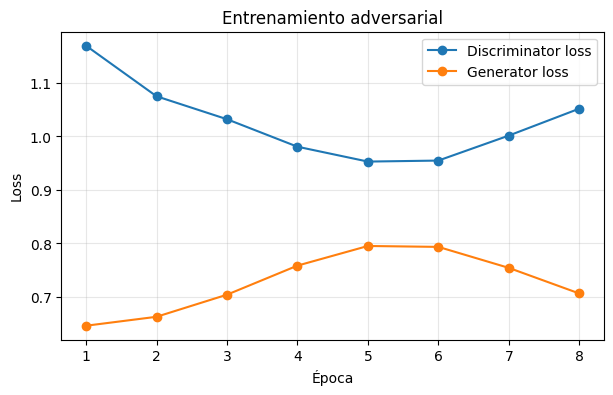

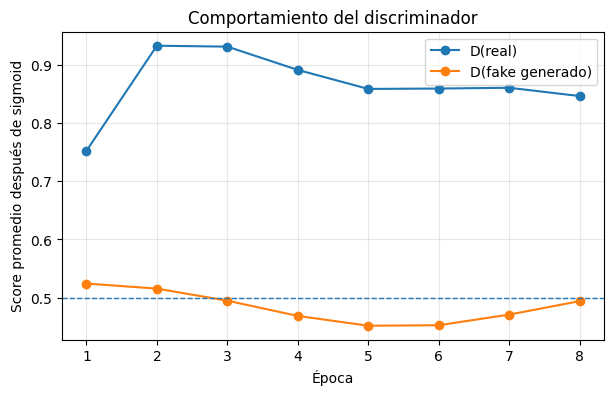

In [ ]:
# ── Curvas de pérdida ───────────────────────────────────────────────────
epochs_range = range(1, len(history["g_loss"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, history["d_loss"], marker="o", label="Discriminator loss")
plt.plot(epochs_range, history["g_loss"], marker="o", label="Generator loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Entrenamiento adversarial")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, history["d_real_score"], marker="o", label="D(real)")
plt.plot(epochs_range, history["d_fake_score"], marker="o", label="D(fake generado)")
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.xlabel("Época")
plt.ylabel("Score promedio después de sigmoid")
plt.title("Comportamiento del discriminador")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---

## 5. Visualización de imágenes generadas

Para visualizar imágenes generadas por una red con `tanh`, debemos convertirlas de `[-1, 1]` a `[0, 1]`:

\[
x_{vis} = \frac{x + 1}{2}
\]

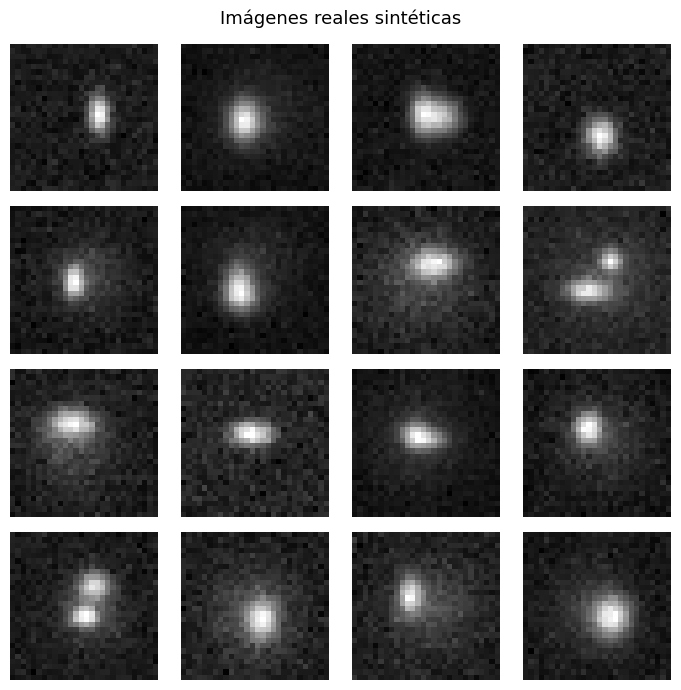

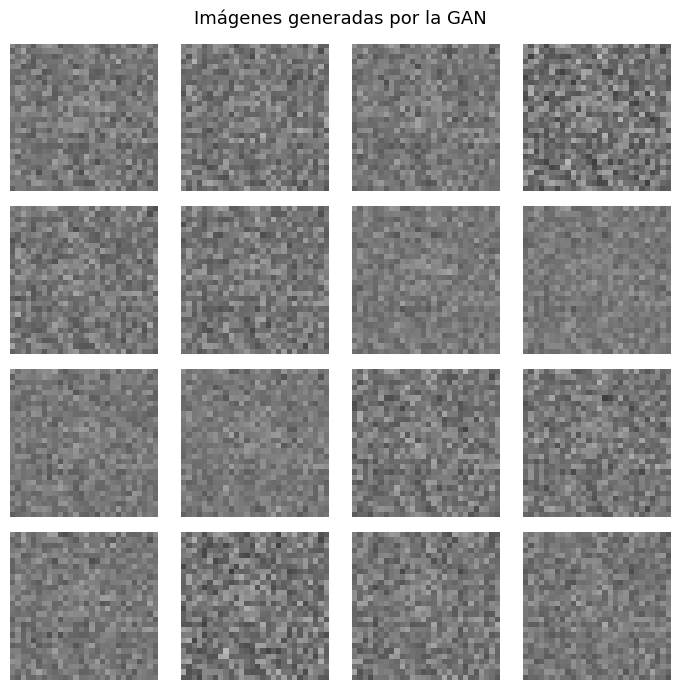

In [ ]:
def generate_images(G, n_images=16, latent_dim=16, device="cpu"):
    G.eval()
    with torch.no_grad():
        # TODO 22: genera ruido latente y produce imágenes con G.
        z = torch.randn(n_images, latent_dim, device=device)
        generated = G(z)

    # TODO 23: convierte de [-1, 1] a [0, 1] para visualizar.
    generated = (generated + 1) / 2
    generated = torch.clamp(generated, 0, 1)
    return generated

generated_images = generate_images(G, n_images=16, latent_dim=latent_dim, device=device)

show_image_grid(X_real, title="Imágenes reales sintéticas", n=16)
show_image_grid(generated_images, title="Imágenes generadas por la GAN", n=16)


---

## 6. Evaluación básica de una GAN

Una GAN no se evalúa igual que un clasificador.  
No hay etiquetas de clase ni matriz de confusión. En este challenge usaremos tres chequeos simples:

1. **Estadísticas de intensidad:** media y desviación estándar.
2. **Fracción de píxeles activos:** porcentaje de píxeles con intensidad mayor a 0.35.
3. **Diversidad:** distancia promedio entre imágenes generadas.

Estas métricas no reemplazan evaluación clínica, pero ayudan a detectar fallas evidentes.

In [ ]:
def pairwise_diversity(images):
    if isinstance(images, torch.Tensor):
        images = images.detach().cpu().numpy()
    flat = images.reshape(images.shape[0], -1)
    dists = []
    for i in range(len(flat)):
        for j in range(i + 1, len(flat)):
            dists.append(np.linalg.norm(flat[i] - flat[j]))
    return float(np.mean(dists))


real_sample = torch.tensor(X_real[:64])
gen_sample = generate_images(G, n_images=64, latent_dim=latent_dim, device=device)

# TODO 24: completa las estadísticas básicas para comparar reales vs generadas.
summary = pd.DataFrame({
    "Conjunto": ["Real sintético", "Generado"],
    "Intensidad media": [real_sample.mean().item(), gen_sample.mean().item()],
    "Desv. estándar": [real_sample.std().item(), gen_sample.std().item()],
    "Píxeles activos > 0.35": [(real_sample > 0.35).float().mean().item(), (gen_sample > 0.35).float().mean().item()],
    "Diversidad promedio": [pairwise_diversity(real_sample), pairwise_diversity(gen_sample)]
})

summary


,Conjunto,Intensidad media,Desv. estándar,Píxeles activos > 0.35,Diversidad promedio
0,Real sintético,0.159872,0.135580,0.063377,3.724082
1,Generado,0.466766,0.074104,0.951172,1.669195


### Paso 6.2 — Chequeo de sobreajuste visual: vecino real más cercano

Un riesgo de modelos generativos es memorizar ejemplos.  
Como chequeo simple, compararemos una imagen generada con la imagen real más cercana en distancia euclidiana.

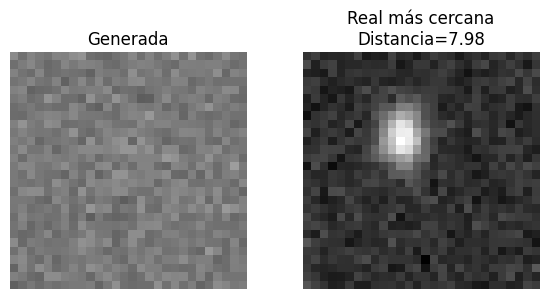

In [ ]:
def nearest_real_image(generated_img, real_images):
    # generated_img: (1, H, W), real_images: (N, 1, H, W), ambos en [0, 1]

    # TODO 25: aplana imagen generada e imágenes reales.
    gen_flat = generated_img.flatten()
    real_flat = real_images.reshape(real_images.shape[0], -1)

    # TODO 26: calcula distancias euclidianas y selecciona el índice menor.
    distances = np.linalg.norm(real_flat - gen_flat, axis=1)
    idx = np.argmin(distances)
    return idx, distances[idx]

gen_np = gen_sample[0].numpy()
idx_near, dist_near = nearest_real_image(gen_np, X_real)

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(np.squeeze(gen_np), cmap="gray", vmin=0, vmax=1)
plt.title("Generada")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.squeeze(X_real[idx_near]), cmap="gray", vmin=0, vmax=1)
plt.title(f"Real más cercana\nDistancia={dist_near:.2f}")
plt.axis("off")

plt.tight_layout()
plt.show()


---

## 7. Interpretación final

### 7.1 — Análisis visual

**Pregunta F1:** Describe brevemente si las imágenes generadas se parecen al dataset real.

Respuesta:  
Las imágenes generadas presentan patrones brillantes y formas suaves similares a las del dataset sintético original. Aunque no son idénticas a las imágenes reales, la GAN logró capturar las características generales de distribución, intensidad y estructura presentes en los datos de entrenamiento.

### 7.2 — Entrenamiento adversarial

**Pregunta F2:** ¿Por qué en una GAN no basta con mirar solo la pérdida del generador?

Respuesta:  
Porque el entrenamiento de una GAN depende de la interacción entre el generador y el discriminador. Una pérdida baja del generador no garantiza que las imágenes sean realistas o diversas, por lo que también es necesario analizar el desempeño del discriminador y la calidad visual de las muestras generadas.

### 7.3 — Riesgo clínico

**Pregunta F3:** Menciona dos riesgos de usar imágenes sintéticas en un contexto biomédico.

Respuesta:  
1. Las imágenes sintéticas pueden contener artefactos o características que no existen en pacientes reales, generando conclusiones erróneas.
2. Un modelo entrenado excesivamente con datos sintéticos podría no generalizar correctamente a datos clínicos reales.

### 7.4 — Posible mejora

**Pregunta F4:** Propón una mejora para este modelo si se quisiera avanzar hacia imágenes biomédicas más realistas.

Respuesta:  
Una mejora sería utilizar una DCGAN (Deep Convolutional GAN) o una GAN más avanzada basada en convoluciones, ya que estas arquitecturas capturan mejor las estructuras espaciales de las imágenes y pueden generar muestras biomédicas más realistas y detalladas.
